# Job Placement Analysis
### Business Question: What factors determine whether a fresh graduate gets hired?
**Tools:** Python (Pandas, Matplotlib) | SQL (MySQL) | Power BI

## Load the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Job_Placement_Data.csv')

# Basic check
print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (215, 13)

First 5 rows:


,gender,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_subject,degree_percentage,undergrad_degree,work_experience,emp_test_percentage,specialisation,mba_percent,status
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed


## Check Data Quality

In [2]:
# Check for missing values
print('Missing values in each column:')
print(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())

print('\nStatus column unique values:', df['status'].unique())
print('Work experience unique values:', df['work_experience'].unique())

Missing values in each column:
gender                 0
ssc_percentage         0
ssc_board              0
hsc_percentage         0
hsc_board              0
hsc_subject            0
degree_percentage      0
undergrad_degree       0
work_experience        0
emp_test_percentage    0
specialisation         0
mba_percent            0
status                 0
dtype: int64

Duplicate rows: 0

Status column unique values: ['Placed' 'Not Placed']
Work experience unique values: ['No' 'Yes']


## Clean the Data

In [3]:
# Data check result: 215 students, 13 columns, 0 missing values
# No major cleaning needed — data is already clean

# Add a binary column for easy calculations (Placed=1, Not Placed=0)
df['placed_binary'] = (df['status'] == 'Placed').astype(int)

print('Placed:', df['placed_binary'].sum())
print('Not Placed:', (df['placed_binary'] == 0).sum())
print('Total:', len(df))
print('\nClean dataset ready!')

Placed: 148
Not Placed: 67
Total: 215

Clean dataset ready!


## Finding 1: Placement Rate Overall

--- Overall Placement ---
Placed: 148 students (68.8%)
Not Placed: 67 students (31.2%)


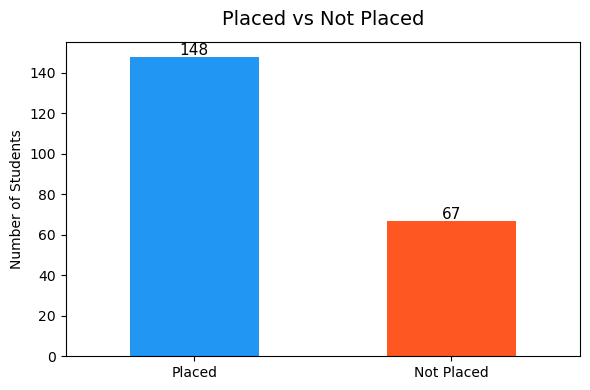

Chart saved as chart1_overall.png


In [4]:
# Overall placement rate
placement_counts = df['status'].value_counts()
placement_pct = df['status'].value_counts(normalize=True) * 100

print('--- Overall Placement ---')
for status in placement_counts.index:
    print(f'{status}: {placement_counts[status]} students ({placement_pct[status]:.1f}%)')

# Chart
fig, ax = plt.subplots(figsize=(6, 4))
placement_counts.plot(kind='bar', ax=ax, color=['#2196F3', '#FF5722'], edgecolor='none')
ax.set_title('Placed vs Not Placed', fontsize=14, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Number of Students')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(placement_counts):
    ax.text(i, v + 1, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('chart1_overall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as chart1_overall.png')

## Cell 5 — Finding 2: Work Experience Impact

--- Work Experience vs Placement Rate ---
                 total_students  placement_rate_pct
work_experience                                    
No                          141                59.6
Yes                          74                86.5

FINDING: Students WITH experience placed at 86.5% vs 59.6% without — a 26.9 point difference.


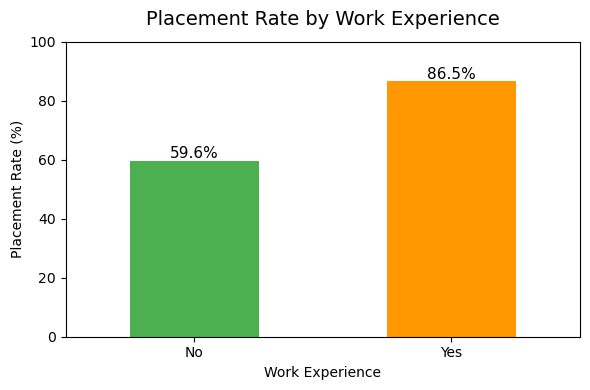

Chart saved as chart2_experience.png


In [5]:
# Placement rate by work experience
exp_group = df.groupby('work_experience')['placed_binary'].agg(['mean', 'count'])
exp_group['placement_rate'] = (exp_group['mean'] * 100).round(1)
exp_group.columns = ['placement_rate_raw', 'total_students', 'placement_rate_pct']

print('--- Work Experience vs Placement Rate ---')
print(exp_group[['total_students', 'placement_rate_pct']])

# Finding summary
yes_rate = exp_group.loc['Yes', 'placement_rate_pct']
no_rate  = exp_group.loc['No',  'placement_rate_pct']
diff     = round(yes_rate - no_rate, 1)
print(f'\nFINDING: Students WITH experience placed at {yes_rate}% vs {no_rate}% without — a {diff} point difference.')

# Chart
fig, ax = plt.subplots(figsize=(6, 4))
exp_group['placement_rate_pct'].plot(kind='bar', ax=ax, color=['#4CAF50', '#FF9800'], edgecolor='none')
ax.set_title('Placement Rate by Work Experience', fontsize=14, pad=12)
ax.set_xlabel('Work Experience')
ax.set_ylabel('Placement Rate (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(exp_group['placement_rate_pct']):
    ax.text(i, v + 1, f'{v}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('chart2_experience.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as chart2_experience.png')

## Cell 6 — Finding 3: Specialisation Impact

--- Specialisation vs Placement Rate ---
Mkt&Fin: 79.2% placement rate (120 students)
Mkt&HR: 55.8% placement rate (95 students)


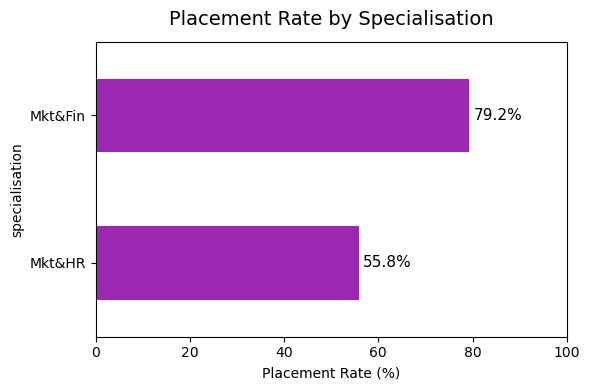

Chart saved as chart3_specialisation.png


In [6]:
# Placement rate by specialisation
spec_group = df.groupby('specialisation')['placed_binary'].agg(['mean', 'count'])
spec_group['placement_rate'] = (spec_group['mean'] * 100).round(1)

print('--- Specialisation vs Placement Rate ---')
for spec in spec_group.index:
    rate  = spec_group.loc[spec, 'placement_rate']
    total = spec_group.loc[spec, 'count']
    print(f'{spec}: {rate}% placement rate ({total} students)')

# Chart
fig, ax = plt.subplots(figsize=(6, 4))
spec_group['placement_rate'].sort_values().plot(kind='barh', ax=ax, color='#9C27B0', edgecolor='none')
ax.set_title('Placement Rate by Specialisation', fontsize=14, pad=12)
ax.set_xlabel('Placement Rate (%)')
ax.set_xlim(0, 100)
for i, v in enumerate(spec_group['placement_rate'].sort_values()):
    ax.text(v + 1, i, f'{v}%', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('chart3_specialisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as chart3_specialisation.png')

## Export Clean Data

In [7]:
# Export clean dataset for Power BI
df.to_csv('clean_placements.csv', index=False)
print('Clean file exported: clean_placements.csv')
print('Use this file in Power BI')

# Final summary of all findings
print('\n===== PROJECT FINDINGS SUMMARY =====')
print(f'Total students analysed : 215')
placed_count = df['placed_binary'].sum()
placed_pct   = round(placed_count / len(df) * 100, 1)
print(f'Overall placement rate  : {placed_pct}%')
print(f'Work experience impact  : {diff} percentage points higher when Yes')
print('======================================')

Clean file exported: clean_placements.csv
Use this file in Power BI

===== PROJECT FINDINGS SUMMARY =====
Total students analysed : 215
Overall placement rate  : 68.8%
Work experience impact  : 26.9 percentage points higher when Yes
